In [30]:
import random
from datetime import datetime

import pandas as pd

from energymanagementrl.pv_prod_simulation.main import run_energy_production_prediction, analyze_production, WeatherType
from energymanagementrl.pv_prod_simulation.simulation import PanelModel, ArrayConfig, PlantConfig
from matplotlib import pyplot as plt
from tqdm import tqdm

In [31]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [ ]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=9, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=9, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
results_df = run_energy_production_prediction(
    plant_config,
    '2024-03-30 00:00',
    '2024-11-21 23:55',
    WeatherType.open_meteo
)
analyze_production(results_df)

In [ ]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=9, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=9, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
results_df = run_energy_production_prediction(
    plant_config,
    '2024-03-30 00:00',
    '2024-11-22 00:00',
    WeatherType.open_meteo
)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=14, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=14, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
pv_production_simulation = pd.concat([run_energy_production_prediction(
    plant_config,
    '2024-11-22 00:00',
    '2024-12-10 00:00',
    WeatherType.open_meteo
), results_df], axis=0)
analyze_production(pv_production_simulation)
pv_production_simulation.index = pv_production_simulation.index.astype('int64') // 10 ** 9
pv_production_simulation.sort_index(inplace=True)


In [ ]:
pv_production_simulation.info()

In [ ]:
pv_production_simulation.to_csv('../data/pv_production_simulation.csv')

In [ ]:
plant_stat_history = pd.read_csv('../data/plant_stat_history.csv', index_col=0)
pv_production_simulation = pd.read_csv('../data/pv_production_simulation.csv', index_col=0)
pv_production_simulation = pv_production_simulation[~pv_production_simulation.index.duplicated(keep='first')]
pv_production_simulation.index = (pd.to_datetime(pv_production_simulation.index, unit='s'))
plant_stat_history.index = (pd.to_datetime(plant_stat_history.index, unit='s'))

In [ ]:
pv_production_5min = pv_production_simulation.resample('5T').interpolate(method='linear')

In [473]:
comparison_df = pd.concat([plant_stat_history[['prodPower', 'SOC']], pv_production_5min.inverter_ac], axis=1).dropna()
comparison_df = comparison_df[comparison_df.index > datetime.strptime('2024-08-20', '%Y-%m-%d')]
comparison_df.loc[comparison_df.SOC >= 90] = float('NaN')
comparison_df.loc[comparison_df.inverter_ac == 0] = float('NaN')
comparison_df['E'] = comparison_df.prodPower - comparison_df.inverter_ac
comparison_df['E_PCT'] = comparison_df['E'].pct_change()
comparison_df['AE'] = abs(comparison_df['E'])
comparison_df['SPE'] = comparison_df['E'] / (abs(comparison_df.inverter_ac))
comparison_df['SAPE'] = comparison_df['AE'] / (abs(comparison_df.inverter_ac))

/tmp/ipykernel_119163/1039029993.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  comparison_df['E_PCT'] =comparison_df['E'].pct_change()


In [474]:
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
    "latitude": 37.6,
    "longitude": 14.95,
    "start_date": "2024-08-20",
    "end_date": "2024-12-09",
    "hourly": ["cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_cloud_cover = hourly.Variables(0).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(1).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(2).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"
)}
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high

hourly_dataframe = pd.DataFrame(data=hourly_data)
hourly_dataframe.set_index("date", inplace=True)
print(hourly_dataframe)

Coordinates 37.5625°N 15.0°E
Elevation 541.0 m asl
Timezone None None
Timezone difference to GMT+0 0 s
                           cloud_cover  cloud_cover_low  cloud_cover_mid  \
date                                                                       
2024-08-20 00:00:00+00:00         13.0             13.0              0.0   
2024-08-20 01:00:00+00:00         10.0             10.0              0.0   
2024-08-20 02:00:00+00:00         22.0             22.0              0.0   
2024-08-20 03:00:00+00:00         90.0             22.0              0.0   
2024-08-20 04:00:00+00:00        100.0             18.0             10.0   
...                                ...              ...              ...   
2024-12-09 19:00:00+00:00          0.0              0.0              0.0   
2024-12-09 20:00:00+00:00          4.0              3.0              3.0   
2024-12-09 21:00:00+00:00          0.0              0.0              0.0   
2024-12-09 22:00:00+00:00          2.0              2.0      

In [475]:
hourly_dataframe.index = pd.to_datetime(hourly_dataframe.index.astype('int') // 10 ** 9, unit='s')
from scipy.ndimage import gaussian_filter1d

# Resample and interpolate
hourly_dataframe_5min = hourly_dataframe.resample('5min').interpolate(method='linear')

# Apply Gaussian smoothing
sigma = 3  # Adjust sigma for smoothing level
hourly_dataframe_5min['cloud_cover_high'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_high'].values, sigma)
hourly_dataframe_5min['cloud_cover_low'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_low'].values, sigma)
hourly_dataframe_5min['cloud_cover_mid'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover_mid'].values, sigma)
hourly_dataframe_5min['cloud_cover'] = gaussian_filter1d(hourly_dataframe_5min['cloud_cover'].values, sigma) / 100
hourly_dataframe_5min = hourly_dataframe_5min

<Axes: xlabel='date'>

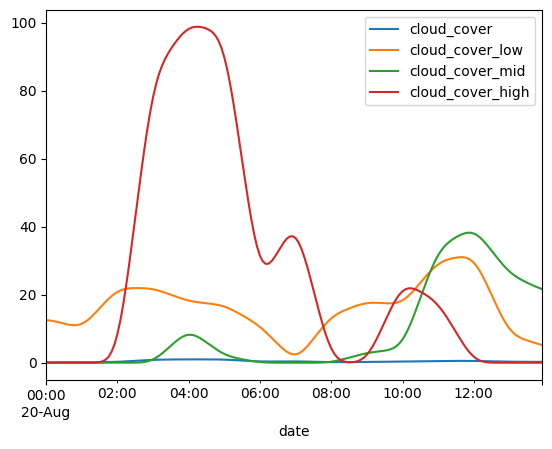

In [476]:
hourly_dataframe_5min[:24 * 7].plot()

In [477]:
complete_df = pd.concat([hourly_dataframe_5min, comparison_df], axis=1)
complete_df[complete_df.SOC.isnull()] = float('NaN')

  0%|          | 0/16 [00:00<?, ?it/s]

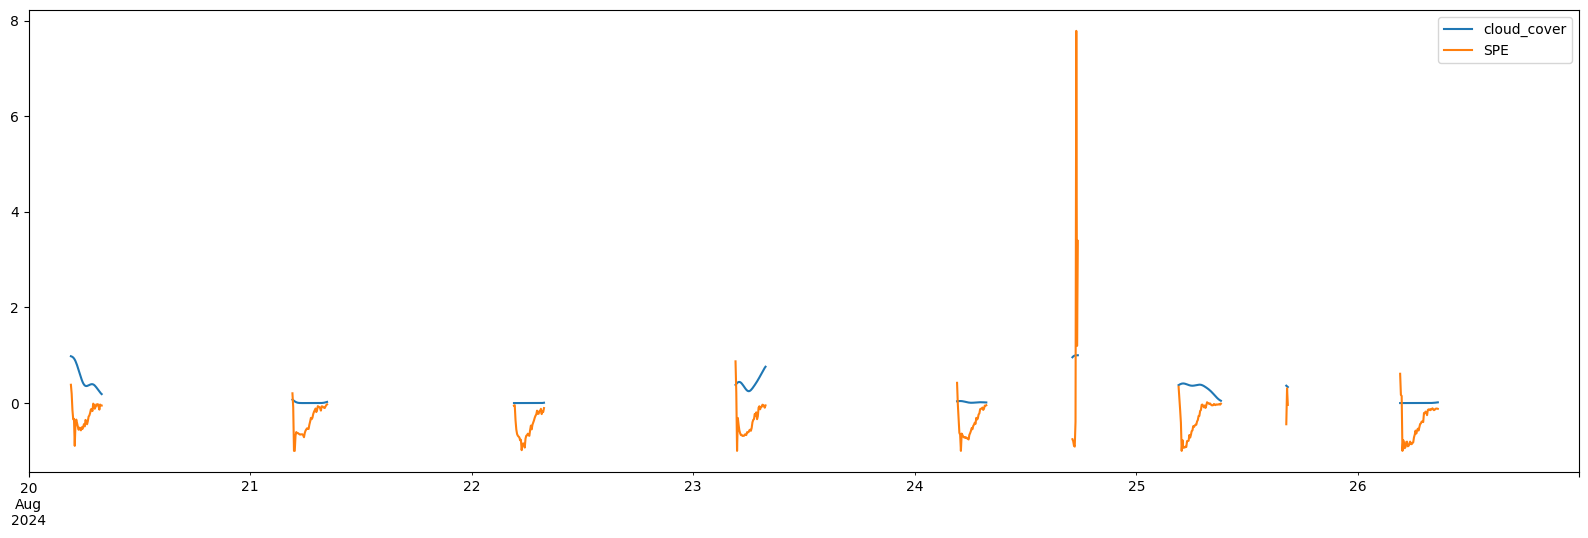

  6%|▋         | 1/16 [00:00<00:04,  3.04it/s]

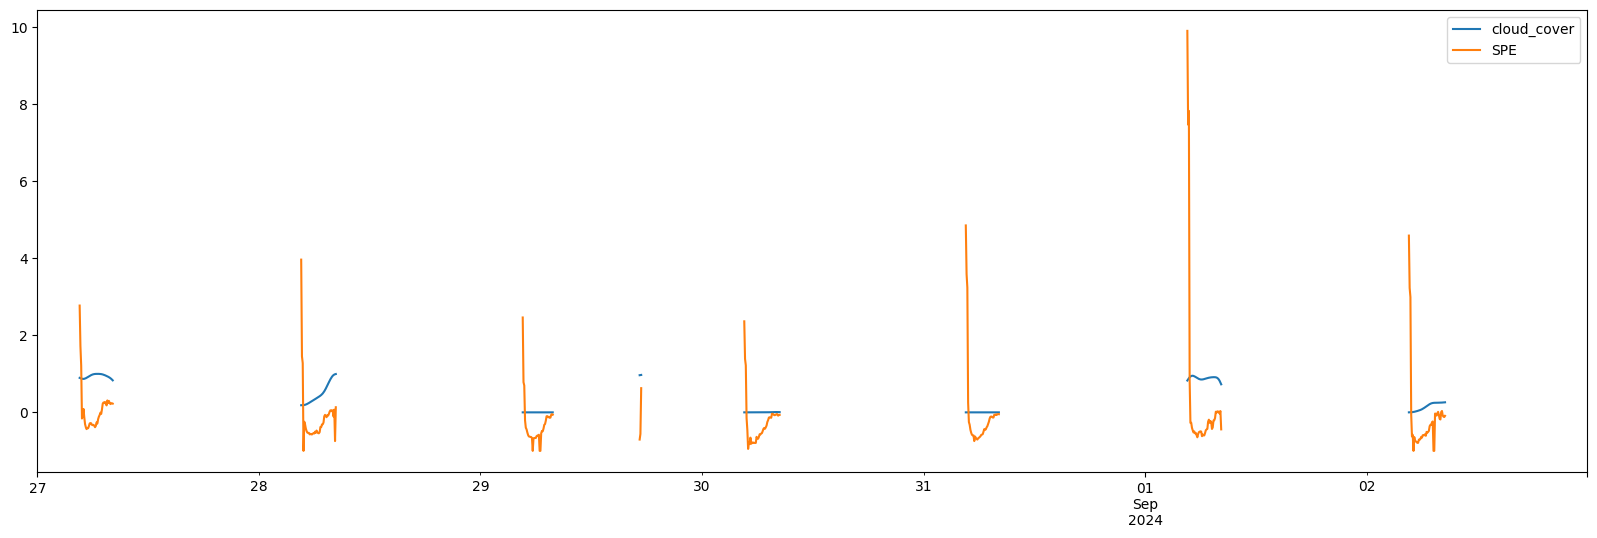

 12%|█▎        | 2/16 [00:00<00:04,  3.47it/s]

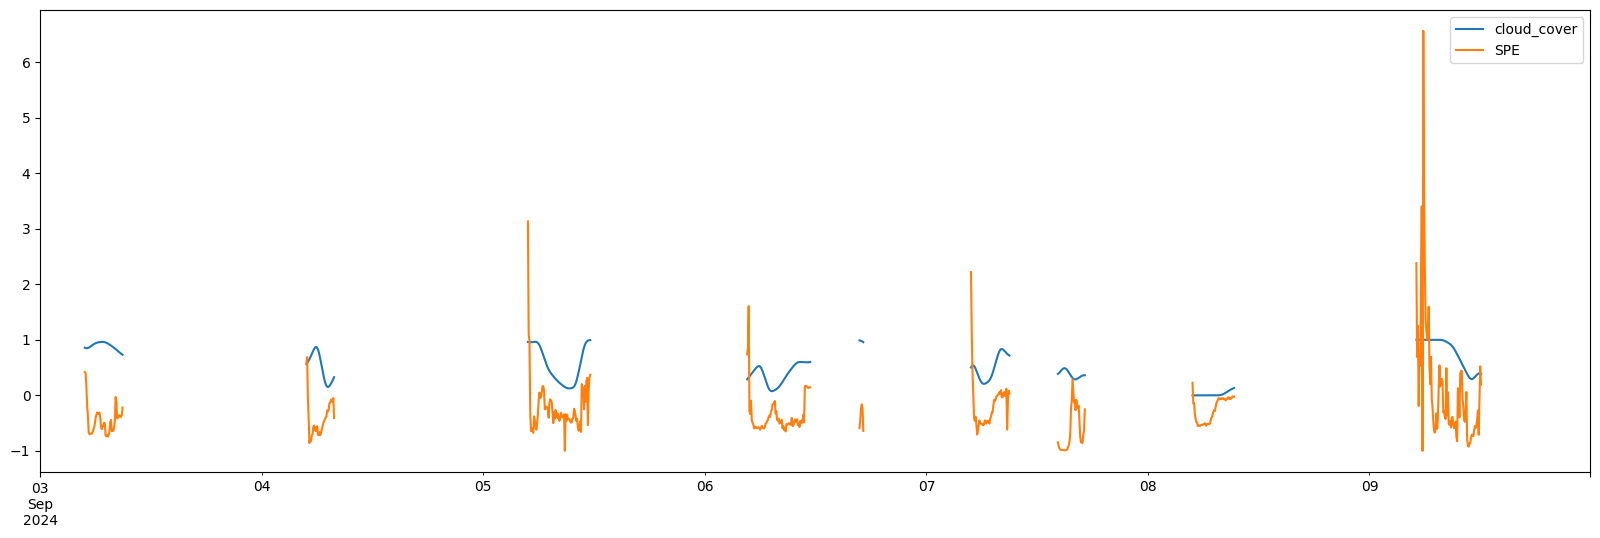

 19%|█▉        | 3/16 [00:00<00:03,  3.96it/s]

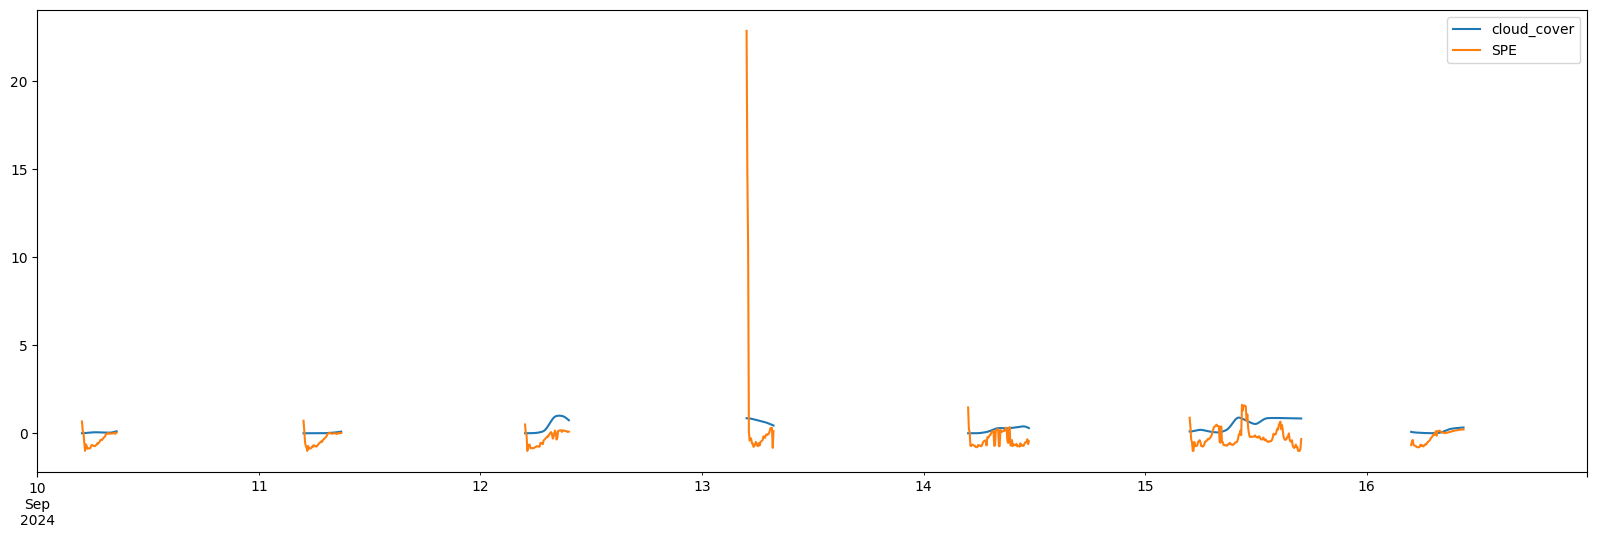

 25%|██▌       | 4/16 [00:00<00:02,  4.61it/s]

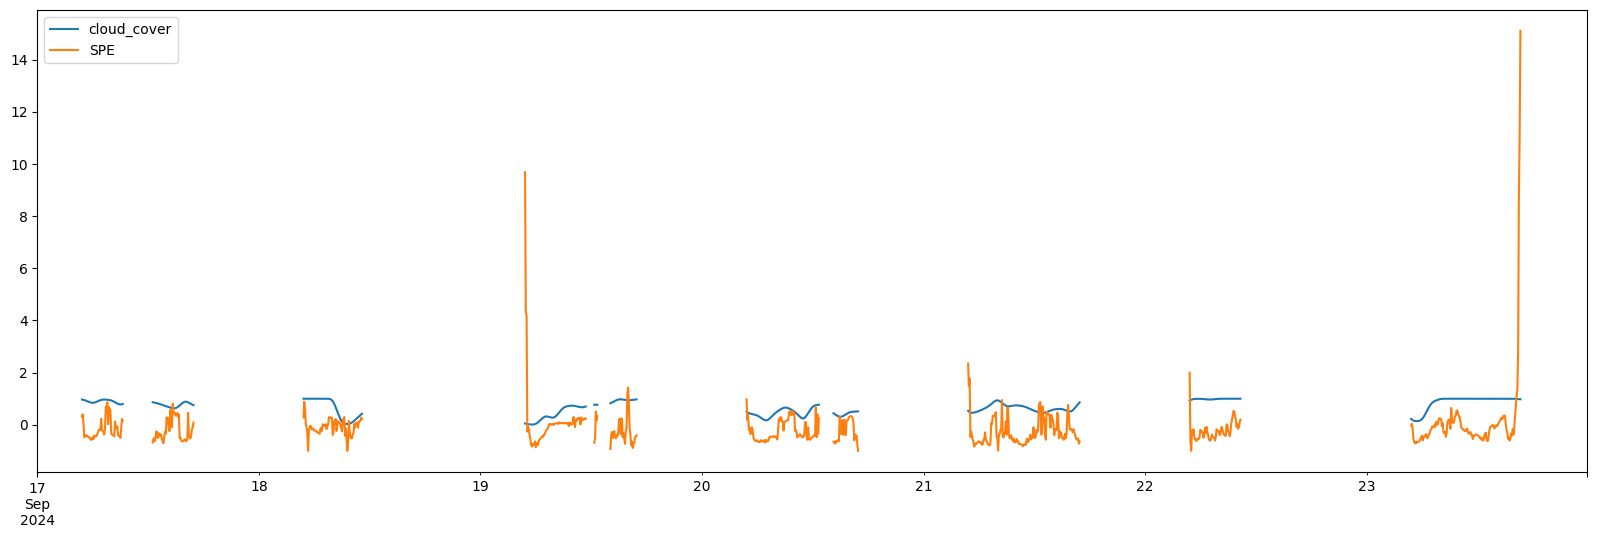

 31%|███▏      | 5/16 [00:01<00:02,  5.20it/s]

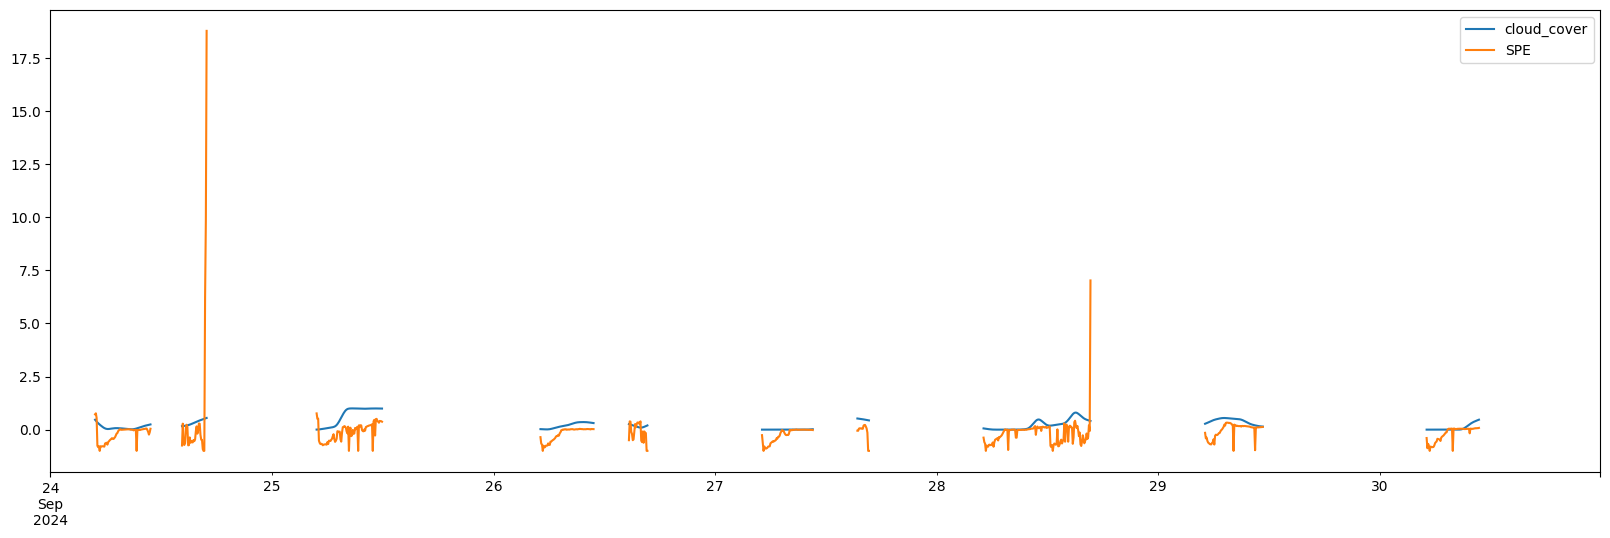

 38%|███▊      | 6/16 [00:01<00:01,  5.49it/s]

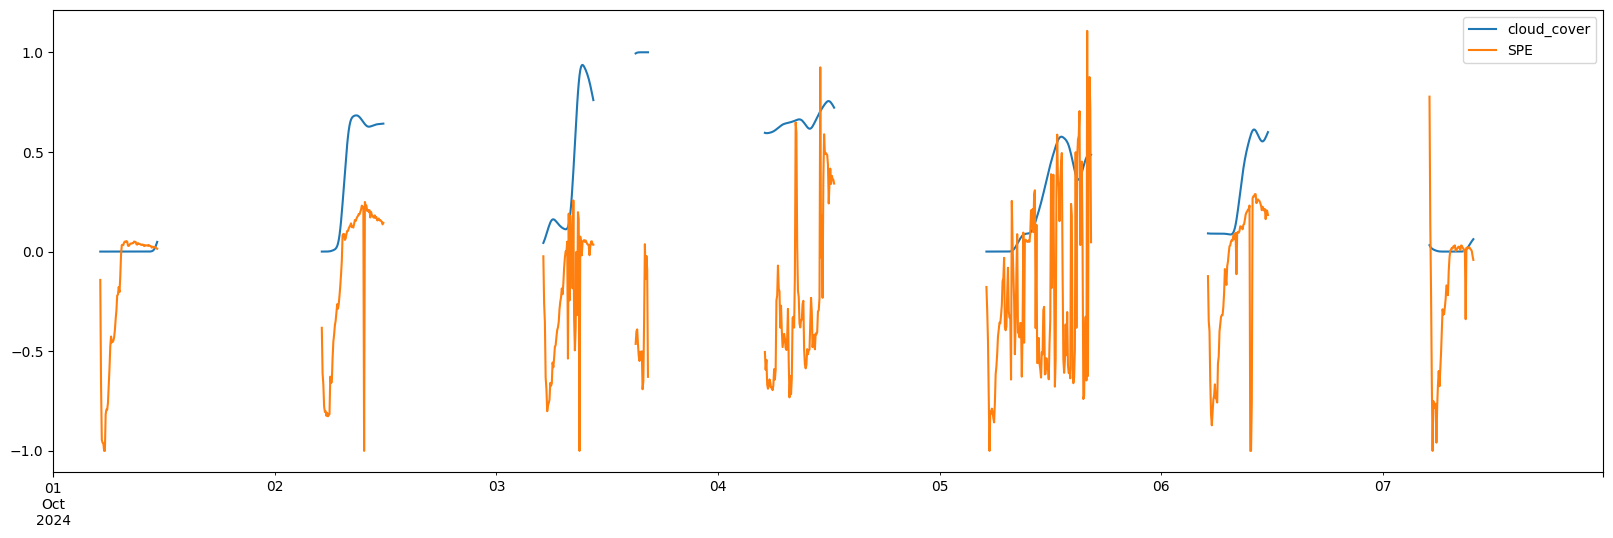

 44%|████▍     | 7/16 [00:01<00:01,  5.92it/s]

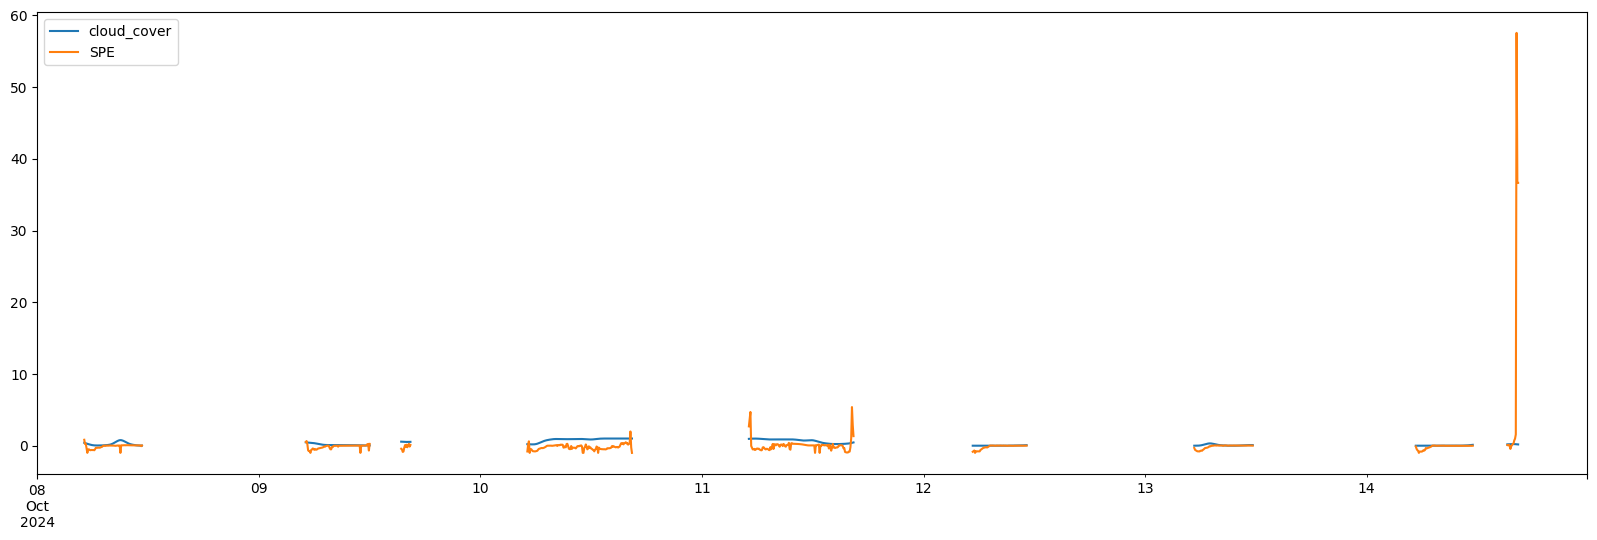

 50%|█████     | 8/16 [00:01<00:01,  6.39it/s]

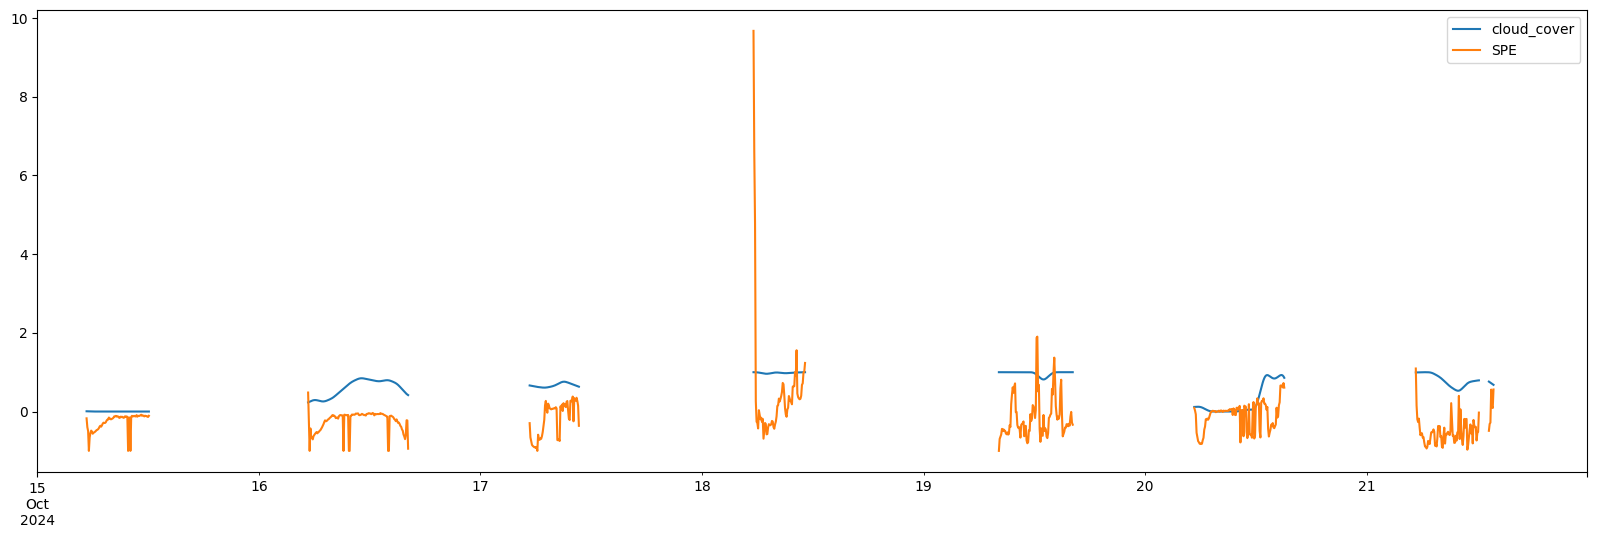

 56%|█████▋    | 9/16 [00:01<00:01,  6.57it/s]

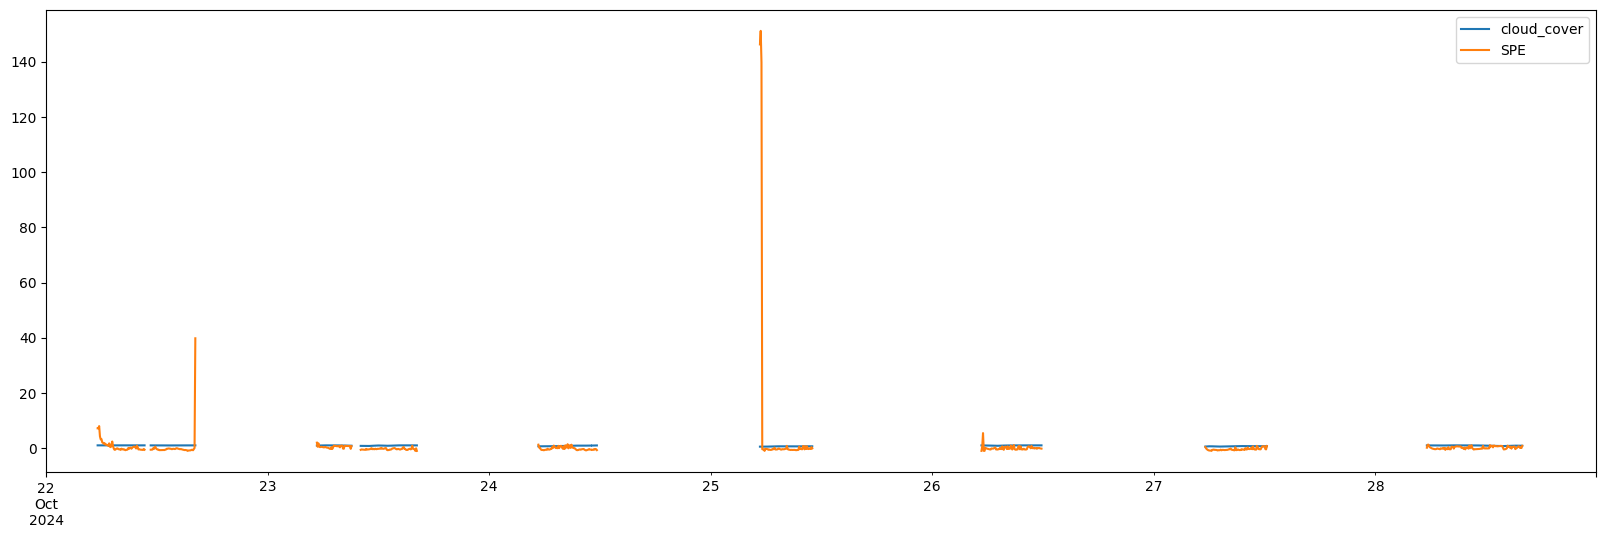

 62%|██████▎   | 10/16 [00:01<00:00,  6.57it/s]

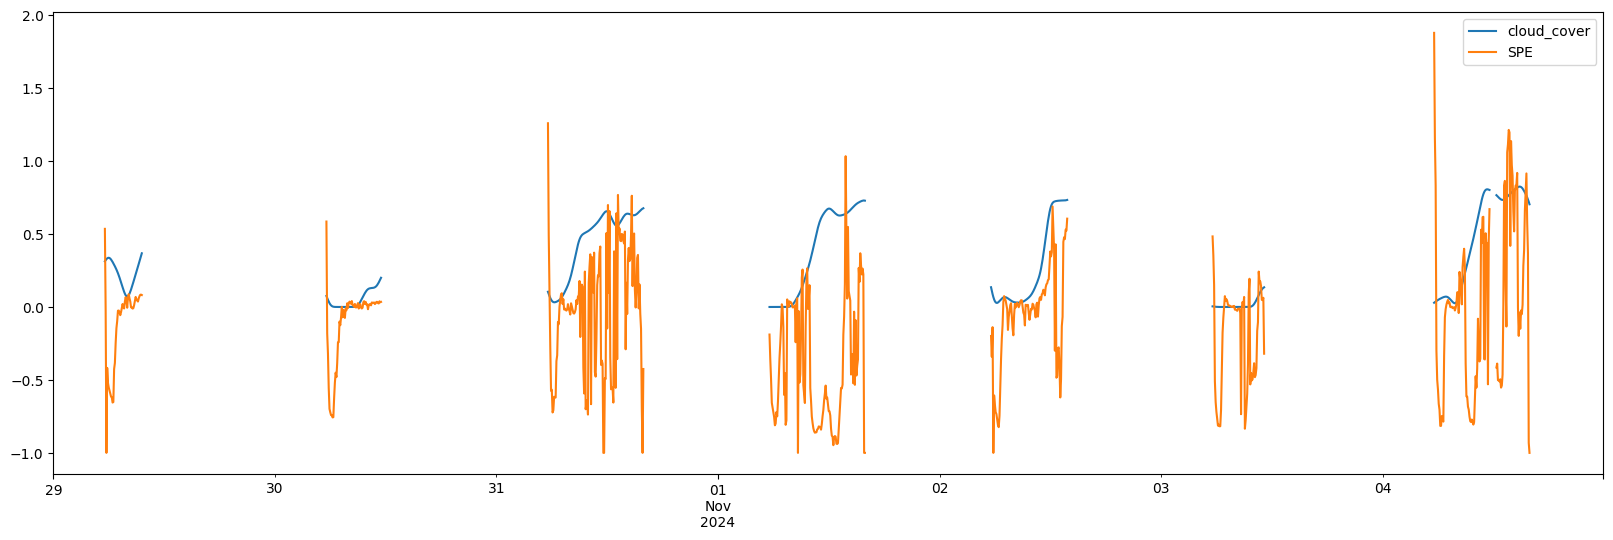

 69%|██████▉   | 11/16 [00:01<00:00,  6.78it/s]

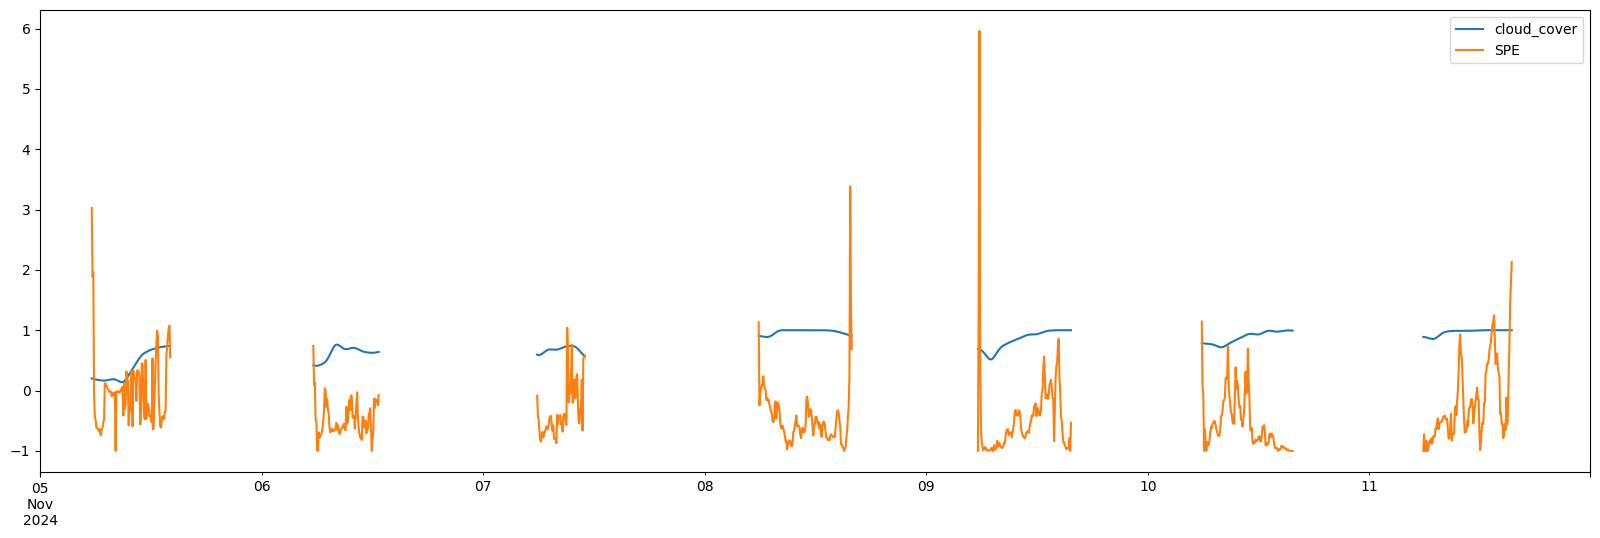

 75%|███████▌  | 12/16 [00:02<00:00,  6.41it/s]

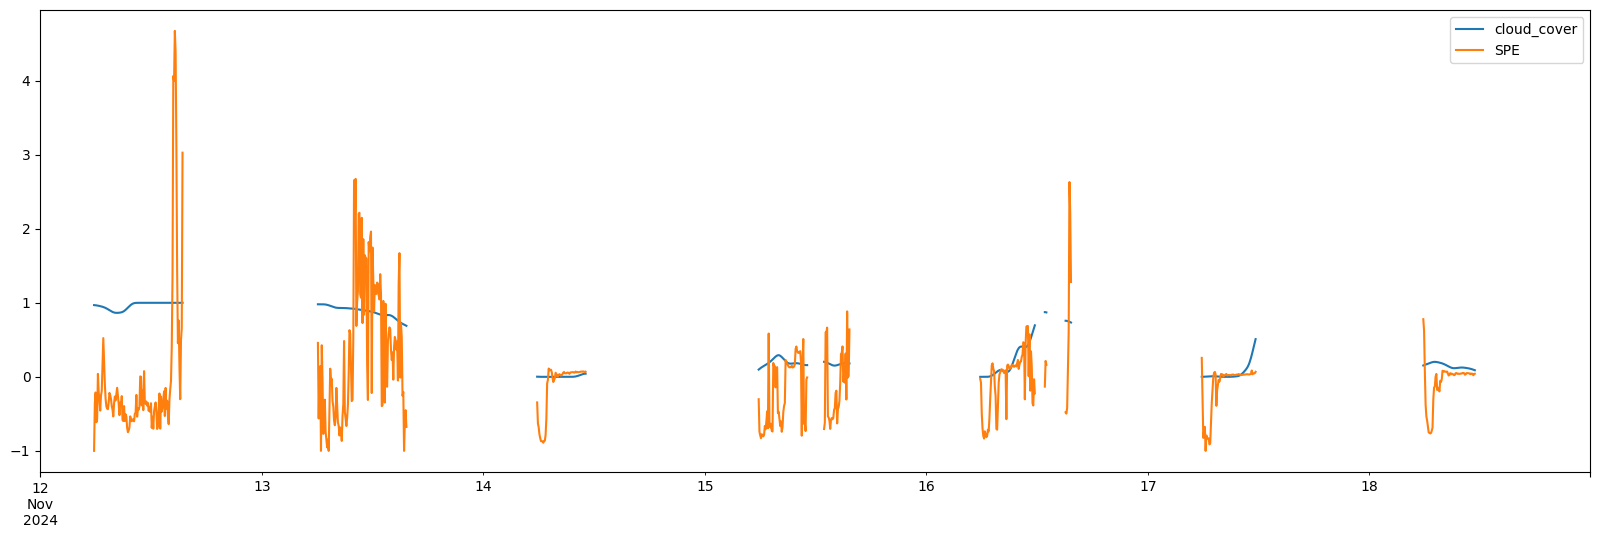

 81%|████████▏ | 13/16 [00:02<00:00,  6.24it/s]

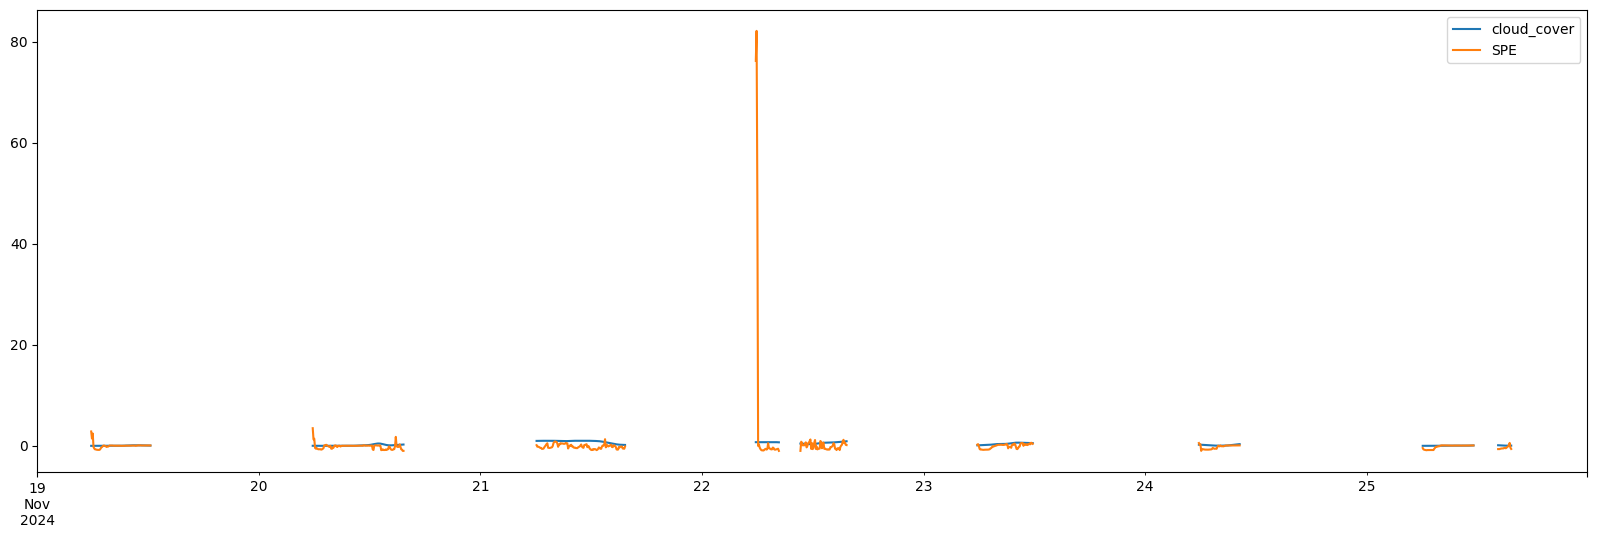

 88%|████████▊ | 14/16 [00:02<00:00,  6.88it/s]

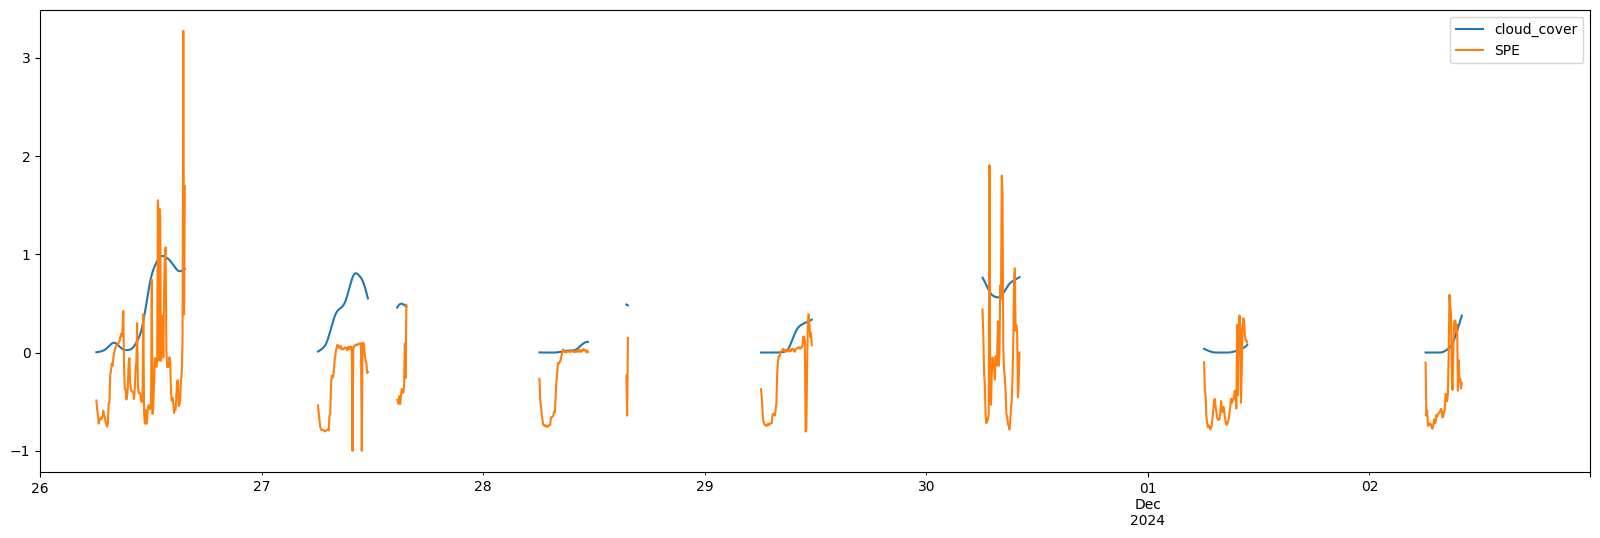

 94%|█████████▍| 15/16 [00:02<00:00,  6.72it/s]

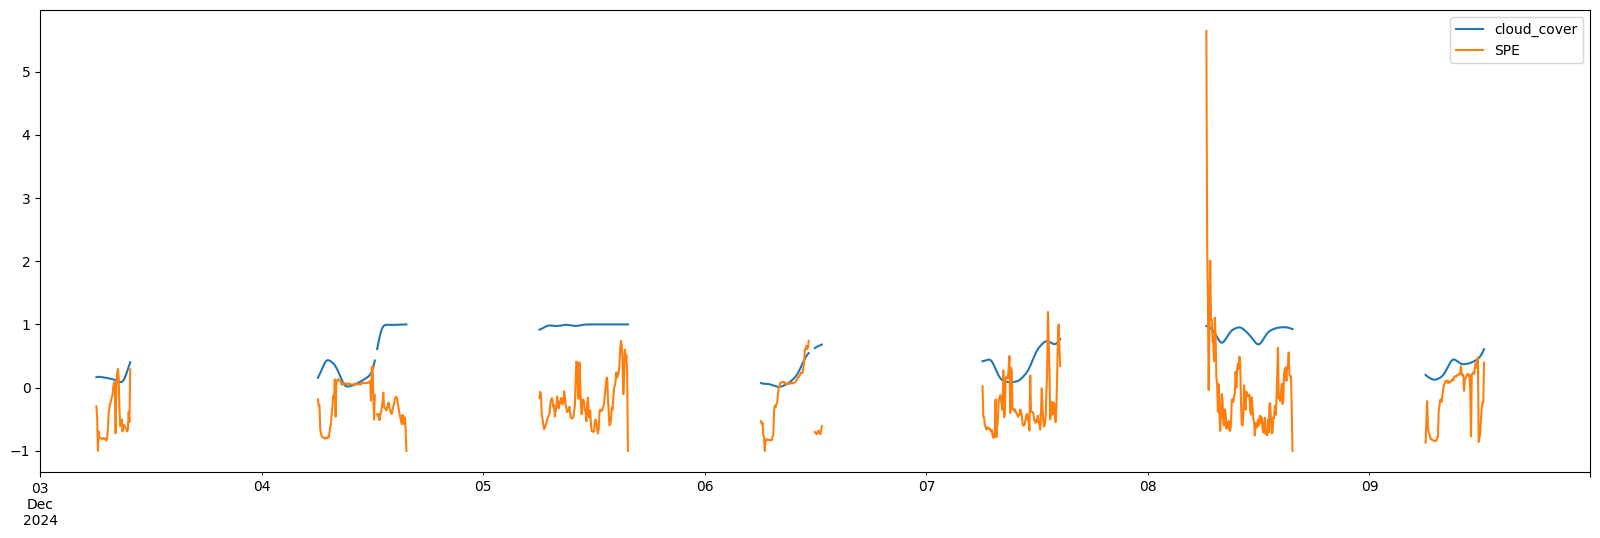

100%|██████████| 16/16 [00:03<00:00,  4.44it/s]


In [478]:


week = 288 * 7

for i in tqdm(range(comparison_df.shape[0] // week)):
    a = i
    b = a + 1
    complete_df[[
        # 'prodPower',
        # 'inverter_ac',
        # 'E',
        'cloud_cover',
        'SPE'
    ]][week * a:288 * 7 * b].plot(figsize=(20, 6))
    plt.show()

In [364]:
# data=complete_df[complete_df['cloud_cover']>.2][['cloud_cover','SPE']].dropna().reset_index(drop=True)
data = complete_df[['cloud_cover', 'SPE']].dropna().reset_index(drop=True)
# data['SPE']=abs(data['SPE'])

In [409]:
import numpy as np

cloud_cover_bins = np.arange(0, 1.1, 0.1)
spe_bins = np.arange(-1.05, 1.15, 0.1)  # Bins for SPE from -1 to 1 with 0.1 interval
density_matrix = np.zeros((len(cloud_cover_bins) - 1, len(spe_bins) - 1))

# For each cloud coverage bin, calculate the distribution of SPE
for i in range(len(cloud_cover_bins) - 1):
    # Get data points within the current cloud coverage range
    mask = (data['cloud_cover'] >= cloud_cover_bins[i]) & (data['cloud_cover'] < cloud_cover_bins[i + 1])
    spe_values = data['SPE'][mask]

    # Create a 2D histogram for the current cloud coverage bin and store it in the density matrix
    density_matrix[i, :], _ = np.histogram(spe_values, bins=spe_bins, density=True)
    density_matrix[i, :] = density_matrix[i, :] / np.sum(density_matrix[i, :])
density_matrix[0:3, :] = 0
density_matrix[0:3, 10] = 1
density_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.0000

In [452]:


def get_spe_error(cloud_cover, cloud_cover_bins, spe_bins, density_matrix):
    """
    Get an SPE error based on cloud coverage and the density matrix.

    Parameters:
        cloud_cover (float): The cloud coverage value (0 to 1).
        cloud_cover_bins (array): Bins defining the cloud coverage ranges.
        spe_bins (array): Bins defining the SPE value ranges.
        density_matrix (2D array): Probability density matrix for SPE values at different cloud cover levels.

    Returns:
        float: A sampled SPE error value.
    """
    row_index = np.clip(np.digitize(cloud_cover, cloud_cover_bins) - 1, 0, density_matrix.shape[0] - 1)
    probabilities = density_matrix[row_index]
    sampled_index = np.random.choice(len(spe_bins) - 1, p=probabilities)

    return random.uniform(spe_bins[sampled_index], spe_bins[sampled_index + 1])



In [472]:
cloud_cover = 1  # Example cloud coverage value
error = get_spe_error(cloud_cover, cloud_cover_bins, spe_bins, density_matrix)
print(f"SPE Error: {error}")


SPE Error: 0.12834966577575208


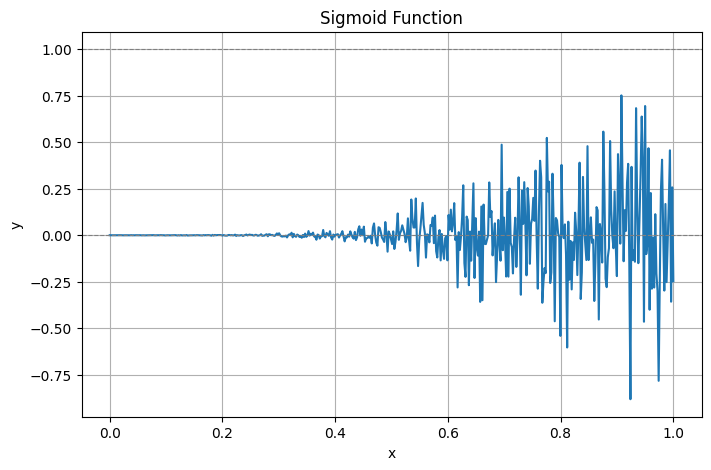

In [20]:
# Precomputed constants
SIGMOID_K = 12
SIGMOID_X0 = (0.3 + 0.98) / 2
SIGMOID_SCALE = 0.9
ERROR_DIVISOR = 3


def simulate_error(cloud_cover: float):
    if not (0 <= cloud_cover <= 1):
        raise ValueError("Cloud cover must be between 0 and 1.")

    # Compute the sigmoid value directly
    error_factor = SIGMOID_SCALE / (
            1 + np.exp(-SIGMOID_K * (cloud_cover - SIGMOID_X0))
    )

    # Generate and clip the error
    return max(-SIGMOID_SCALE, min(SIGMOID_SCALE, np.random.normal(0, error_factor / ERROR_DIVISOR)))


# Generate x values
x = np.linspace(0, 1, 500)
# Compute sigmoid values
y = [simulate_error(a) for a in x]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()


In [28]:
df_0 = pd.read_csv('../data/complete_series.csv', parse_dates=['timestamp'],index_col='timestamp').drop(columns=['Unnamed: 0'])


In [29]:
df

,grid_voltage,consumption_w,production_w
timestamp,,,
2024-04-01 00:00:00,237.4,178.0,0.0
2024-04-01 00:05:00,236.5,175.0,0.0
2024-04-01 00:10:00,237.0,176.0,0.0
2024-04-01 00:15:00,235.8,174.0,0.0
2024-04-01 00:20:00,236.1,174.0,0.0
...,...,...,...
2024-08-19 23:40:00,229.6,299.0,0.0
2024-08-19 23:45:00,230.5,297.0,0.0
2024-08-19 23:50:00,231.9,292.0,0.0
